# Hotel Booking Cancellation & Revenue Intelligence Analytics

**Author:** Pranav Singh

## Business Problem
What factors are associated with hotel booking cancellations, how do cancellations impact potential revenue and occupancy, and what actions can hotels take to improve booking conversion and operational planning?

This notebook walks through the complete analytical workflow: data quality assessment, cleaning, feature engineering, exploratory analysis, cancellation analysis, demand/seasonality analysis, hotel performance comparison, revenue risk analysis, statistical testing, and business recommendations.

**Dataset:** Hotel Booking Demand (Kaggle, Jesse Mostipak; originally published by Antonio, Almeida & Nunes, *Data in Brief*, 2019). 119,390 raw bookings across a City Hotel and a Resort Hotel in Portugal, 2015-2017.

## 1. Setup

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

sns.set_theme(style="whitegrid")
plt.rcParams["figure.dpi"] = 100
pd.set_option("display.max_columns", 50)


## 2. Dataset Overview

In [2]:
df_raw = pd.read_csv("../data/raw/hotel_bookings.csv")
print(f"Shape: {df_raw.shape[0]:,} rows x {df_raw.shape[1]} columns")
df_raw.head()


Shape: 119,390 rows x 32 columns


,hotel,is_canceled,lead_time,arrival_date_year,arrival_date_month,arrival_date_week_number,arrival_date_day_of_month,stays_in_weekend_nights,stays_in_week_nights,adults,children,babies,meal,country,market_segment,distribution_channel,is_repeated_guest,previous_cancellations,previous_bookings_not_canceled,reserved_room_type,assigned_room_type,booking_changes,deposit_type,agent,company,days_in_waiting_list,customer_type,adr,required_car_parking_spaces,total_of_special_requests,reservation_status,reservation_status_date
0,Resort Hotel,0,342,2015,July,27,1,0,0,2,0.0,0,BB,PRT,Direct,Direct,0,0,0,C,C,3,No Deposit,NaN,NaN,0,Transient,0.0,0,0,Check-Out,01-07-15
1,Resort Hotel,0,737,2015,July,27,1,0,0,2,0.0,0,BB,PRT,Direct,Direct,0,0,0,C,C,4,No Deposit,NaN,NaN,0,Transient,0.0,0,0,Check-Out,01-07-15
2,Resort Hotel,0,7,2015,July,27,1,0,1,1,0.0,0,BB,GBR,Direct,Direct,0,0,0,A,C,0,No Deposit,NaN,NaN,0,Transient,75.0,0,0,Check-Out,02-07-15
3,Resort Hotel,0,13,2015,July,27,1,0,1,1,0.0,0,BB,GBR,Corporate,Corporate,0,0,0,A,A,0,No Deposit,304.0,NaN,0,Transient,75.0,0,0,Check-Out,02-07-15
4,Resort Hotel,0,14,2015,July,27,1,0,2,2,0.0,0,BB,GBR,Online TA,TA/TO,0,0,0,A,A,0,No Deposit,240.0,NaN,0,Transient,98.0,0,1,Check-Out,03-07-15


In [3]:
df_raw.dtypes


hotel                                 str
is_canceled                         int64
lead_time                           int64
arrival_date_year                   int64
arrival_date_month                    str
arrival_date_week_number            int64
arrival_date_day_of_month           int64
stays_in_weekend_nights             int64
stays_in_week_nights                int64
adults                              int64
children                          float64
babies                              int64
meal                                  str
country                               str
market_segment                        str
distribution_channel                  str
is_repeated_guest                   int64
previous_cancellations              int64
previous_bookings_not_canceled      int64
reserved_room_type                    str
assigned_room_type                    str
booking_changes                     int64
deposit_type                          str
agent                             

## 3. Data Quality Assessment

In [4]:
missing = df_raw.isnull().sum()
missing = missing[missing > 0].sort_values(ascending=False)
print("Missing values:")
print(missing)
print(f"\nDuplicate rows: {df_raw.duplicated().sum():,}")
print(f"Bookings with zero guests: {((df_raw['adults']==0) & (df_raw['children'].fillna(0)==0) & (df_raw['babies']==0)).sum():,}")
print(f"Negative ADR values: {(df_raw['adr']<0).sum():,}")


Missing values:
company     112593
agent        16340
country        488
children         4
dtype: int64



Duplicate rows: 31,994
Bookings with zero guests: 180
Negative ADR values: 1


## 4. Data Cleaning

Cleaning decisions (see `src/data_cleaning.py` for full documentation):
- `children` missing (4 rows) -> filled with 0
- `country` missing (488 rows) -> labeled "Unknown" (not guessed)
- `agent` / `company` missingness converted to `has_agent` / `has_company` flags rather than imputed IDs
- Exact duplicate rows (31,994, 26.8%) detected and **retained** (no unique Booking ID exists to confirm they are accidental vs. legitimate separate bookings)
- Bookings with zero total guests (180 rows) removed as logically invalid
- Negative ADR values (1 row) set to NaN, excluded from revenue calculations only


In [5]:
import sys
sys.path.append("../src")
from data_cleaning import clean_data, engineer_features

df_clean = clean_data(df_raw)
df = engineer_features(df_clean)
print(f"\nFinal cleaned shape: {df.shape[0]:,} rows x {df.shape[1]} columns")
df.head()


/home/claude/project/notebooks/../src/data_cleaning.py:126: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df["reservation_status_date"] = pd.to_datetime(df["reservation_status_date"], errors="coerce")


Removed 31,994 exact duplicate rows (26.8% of data).
Removed 166 bookings with zero total guests.
Set 1 negative ADR values to NaN (kept row, excluded from revenue calcs).
Rows before cleaning: 119,390 | after cleaning: 87,230 (26.9% removed).
Lead time quartiles used for categorization: Q1=11, Median=49, Q3=125

Final cleaned shape: 87,230 rows x 44 columns


,hotel,is_canceled,lead_time,arrival_date_year,arrival_date_month,arrival_date_week_number,arrival_date_day_of_month,stays_in_weekend_nights,stays_in_week_nights,adults,children,babies,meal,country,market_segment,distribution_channel,is_repeated_guest,previous_cancellations,previous_bookings_not_canceled,reserved_room_type,assigned_room_type,booking_changes,deposit_type,agent,company,days_in_waiting_list,customer_type,adr,required_car_parking_spaces,total_of_special_requests,reservation_status,reservation_status_date,has_agent,has_company,total_guests,total_stay_nights,lead_time_category,arrival_month_num,arrival_date,season,arrival_quarter,is_returning_guest,has_prior_cancellation_history,potential_booking_revenue
0,Resort Hotel,0,342,2015,July,27,1,0,0,2,0,0,BB,PRT,Direct,Direct,0,0,0,C,C,3,No Deposit,NaN,NaN,0,Transient,0.0,0,0,Check-Out,2015-01-07,False,False,2,0,Long Lead (126+ days),7,2015-07-01,Summer,3,False,False,0.0
1,Resort Hotel,0,737,2015,July,27,1,0,0,2,0,0,BB,PRT,Direct,Direct,0,0,0,C,C,4,No Deposit,NaN,NaN,0,Transient,0.0,0,0,Check-Out,2015-01-07,False,False,2,0,Long Lead (126+ days),7,2015-07-01,Summer,3,False,False,0.0
2,Resort Hotel,0,7,2015,July,27,1,0,1,1,0,0,BB,GBR,Direct,Direct,0,0,0,A,C,0,No Deposit,NaN,NaN,0,Transient,75.0,0,0,Check-Out,2015-02-07,False,False,1,1,Last Minute (0-7 days),7,2015-07-01,Summer,3,False,False,75.0
3,Resort Hotel,0,13,2015,July,27,1,0,1,1,0,0,BB,GBR,Corporate,Corporate,0,0,0,A,A,0,No Deposit,304.0,NaN,0,Transient,75.0,0,0,Check-Out,2015-02-07,True,False,1,1,Short Lead (8-49 days),7,2015-07-01,Summer,3,False,False,75.0
4,Resort Hotel,0,14,2015,July,27,1,0,2,2,0,0,BB,GBR,Online TA,TA/TO,0,0,0,A,A,0,No Deposit,240.0,NaN,0,Transient,98.0,0,1,Check-Out,2015-03-07,True,False,2,2,Short Lead (8-49 days),7,2015-07-01,Summer,3,False,False,196.0


## 5. Feature Engineering Summary

In [6]:
print(df["lead_time_category"].value_counts())
print()
print(df["season"].value_counts())
print()
print(df[["total_guests","total_stay_nights","potential_booking_revenue"]].describe())


lead_time_category
Short Lead (8-49 days)       25518
Medium Lead (50-125 days)    21796
Long Lead (126+ days)        21713
Last Minute (0-7 days)       18203
Name: count, dtype: int64

season
Summer    29041
Spring    23733
Autumn    18576
Winter    15880
Name: count, dtype: int64

       total_guests  total_stay_nights  potential_booking_revenue
count  87230.000000       87230.000000               87229.000000
mean       2.029107           3.628534                 394.956436
std        0.790141           2.742948                 369.446365
min        1.000000           0.000000                   0.000000
25%        2.000000           2.000000                 153.000000
50%        2.000000           3.000000                 299.200000
75%        2.000000           5.000000                 504.000000
max       55.000000          69.000000                7590.000000


## 6. Exploratory Data Analysis

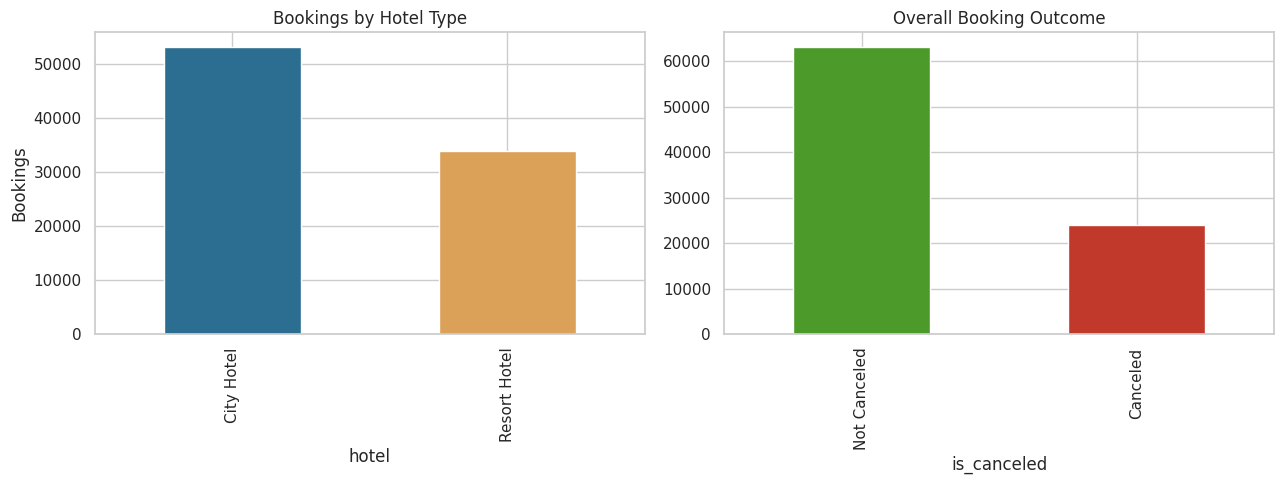

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(13,5))
df["hotel"].value_counts().plot(kind="bar", ax=axes[0], color=["#2c6e91","#dba159"])
axes[0].set_title("Bookings by Hotel Type")
axes[0].set_ylabel("Bookings")

df["is_canceled"].value_counts().rename({0:"Not Canceled",1:"Canceled"}).plot(
    kind="bar", ax=axes[1], color=["#4c9a2a","#c0392b"])
axes[1].set_title("Overall Booking Outcome")
plt.tight_layout()
plt.show()


## 7. Cancellation Analysis

In [8]:
overall_rate = df["is_canceled"].mean()
print(f"Overall cancellation rate: {overall_rate:.2%}")

by_hotel = df.groupby("hotel")["is_canceled"].mean() * 100
print("\nCancellation rate by hotel type:")
print(by_hotel.round(2))

by_segment = df.groupby("market_segment")["is_canceled"].mean().sort_values(ascending=False) * 100
print("\nCancellation rate by market segment:")
print(by_segment.round(2))


Overall cancellation rate: 27.52%

Cancellation rate by hotel type:
hotel
City Hotel      30.10
Resort Hotel    23.48
Name: is_canceled, dtype: float64

Cancellation rate by market segment:
market_segment
Undefined        100.00
Online TA         35.38
Groups            27.06
Aviation          19.91
Offline TA/TO     14.85
Direct            14.75
Complementary     12.28
Corporate         12.12
Name: is_canceled, dtype: float64


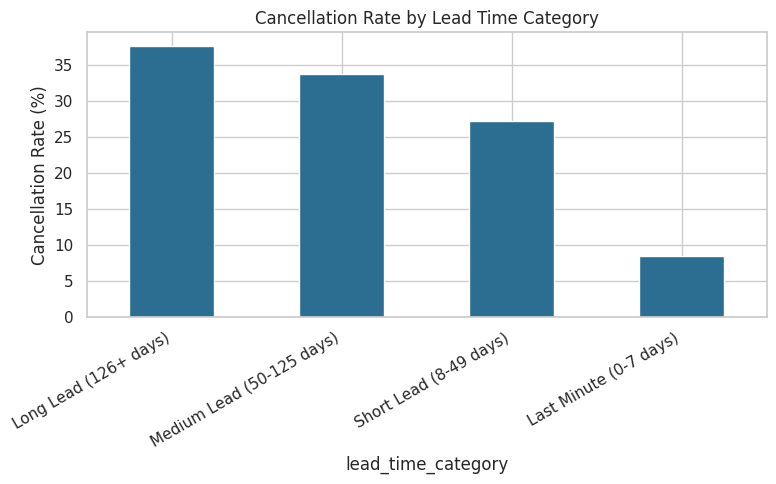

lead_time_category
Long Lead (126+ days)        37.66
Medium Lead (50-125 days)    33.69
Short Lead (8-49 days)       27.26
Last Minute (0-7 days)        8.42
Name: is_canceled, dtype: float64


In [9]:
by_lead = df.groupby("lead_time_category")["is_canceled"].mean().sort_values(ascending=False) * 100
plt.figure(figsize=(8,5))
by_lead.plot(kind="bar", color="#2c6e91")
plt.title("Cancellation Rate by Lead Time Category")
plt.ylabel("Cancellation Rate (%)")
plt.xticks(rotation=30, ha="right")
plt.tight_layout()
plt.show()
print(by_lead.round(2))


**Key finding:** Cancellation likelihood rises with how far in advance a booking is made. Last-minute bookings (0-7 days) cancel at only ~8%, while bookings made 126+ days ahead cancel at ~38%. This is an *association*, not a proven causal mechanism - other unobserved factors (e.g., price-sensitive planning behavior) may explain part of this pattern.

## 8. Demand and Seasonality Analysis

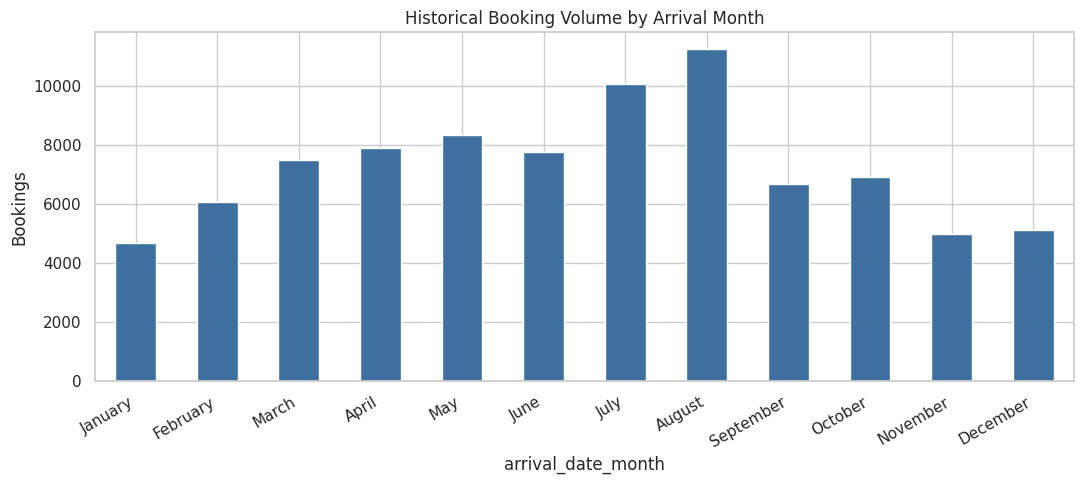

Peak month: August (11,242 bookings)
Lowest month: January (4,685 bookings)


In [10]:
month_order = ["January","February","March","April","May","June","July",
               "August","September","October","November","December"]
monthly = df.groupby("arrival_date_month").size().reindex(month_order)

plt.figure(figsize=(11,5))
monthly.plot(kind="bar", color="#3f6f9f")
plt.title("Historical Booking Volume by Arrival Month")
plt.ylabel("Bookings")
plt.xticks(rotation=30, ha="right")
plt.tight_layout()
plt.show()

print(f"Peak month: {monthly.idxmax()} ({monthly.max():,} bookings)")
print(f"Lowest month: {monthly.idxmin()} ({monthly.min():,} bookings)")


## 9. Hotel Performance Analysis

In [11]:
perf = df.groupby("hotel").agg(
    total_bookings=("is_canceled","count"),
    cancellation_rate=("is_canceled","mean"),
    avg_lead_time=("lead_time","mean"),
    avg_stay_nights=("total_stay_nights","mean"),
)
perf["avg_adr"] = df.dropna(subset=["adr"]).groupby("hotel")["adr"].mean()
perf["cancellation_rate"] = (perf["cancellation_rate"]*100).round(2)
perf = perf.round(2)
perf


,total_bookings,cancellation_rate,avg_lead_time,avg_stay_nights,avg_adr
hotel,,,,,
City Hotel,53274,30.10,77.79,3.14,111.27
Resort Hotel,33956,23.48,83.39,4.39,99.06


## 10. Revenue Risk Analysis

Total potential booking revenue: EUR 34,451,655
Potential revenue at risk (canceled): EUR 11,484,043 (33.3%)


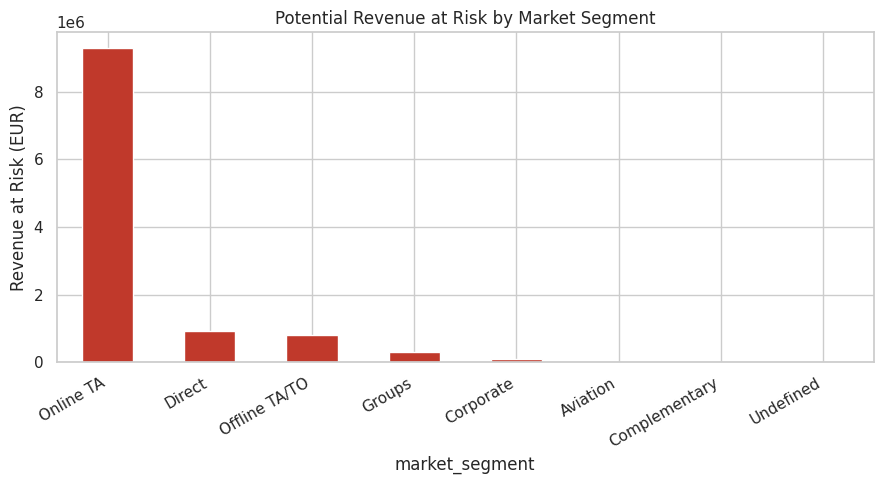

In [12]:
valid = df.dropna(subset=["adr"])
total_potential = valid["potential_booking_revenue"].sum()
at_risk = valid.loc[valid["is_canceled"]==1, "potential_booking_revenue"].sum()
print(f"Total potential booking revenue: EUR {total_potential:,.0f}")
print(f"Potential revenue at risk (canceled): EUR {at_risk:,.0f} ({at_risk/total_potential:.1%})")

risk_by_segment = valid[valid["is_canceled"]==1].groupby("market_segment")["potential_booking_revenue"].sum().sort_values(ascending=False)
plt.figure(figsize=(9,5))
risk_by_segment.plot(kind="bar", color="#c0392b")
plt.title("Potential Revenue at Risk by Market Segment")
plt.ylabel("Revenue at Risk (EUR)")
plt.xticks(rotation=30, ha="right")
plt.tight_layout()
plt.show()


### Revenue Risk Matrix (data-driven thresholds)

In [13]:
seg = valid.groupby("market_segment").agg(
    booking_count=("is_canceled","count"),
    cancellation_rate=("is_canceled","mean"),
    total_potential_revenue=("potential_booking_revenue","sum"),
).reset_index()
seg = seg[seg["booking_count"] >= 200]

vol_median = seg["total_potential_revenue"].median()
cxl_median = seg["cancellation_rate"].median()

def classify(row):
    high_value = row["total_potential_revenue"] >= vol_median
    high_risk = row["cancellation_rate"] >= cxl_median
    if high_value and high_risk: return "High Revenue Risk"
    if high_value and not high_risk: return "Stable Revenue Segment"
    if not high_value and high_risk: return "Growth Opportunity"
    return "Low Priority Segment"

seg["risk_classification"] = seg.apply(classify, axis=1)
seg.sort_values("total_potential_revenue", ascending=False)


,market_segment,booking_count,cancellation_rate,total_potential_revenue,risk_classification
6,Online TA,51553,0.353849,22259326.55,High Revenue Risk
5,Offline TA/TO,13855,0.148466,5416464.95,High Revenue Risk
3,Direct,11780,0.147453,4855042.75,Stable Revenue Segment
4,Groups,4921,0.270677,1238520.72,High Revenue Risk
2,Corporate,4200,0.121190,594144.08,Low Priority Segment
0,Aviation,226,0.199115,83033.36,Growth Opportunity
1,Complementary,692,0.122832,5074.52,Low Priority Segment


## 11. Statistical Analysis

In [14]:
ct = pd.crosstab(df["hotel"], df["is_canceled"])
chi2, p, dof, _ = stats.chi2_contingency(ct)
print(f"Chi-square (Hotel Type vs Cancellation): chi2={chi2:.2f}, p={p:.2e}")

ct2 = pd.crosstab(df["deposit_type"], df["is_canceled"])
chi2b, pb, dofb, _ = stats.chi2_contingency(ct2)
print(f"Chi-square (Deposit Type vs Cancellation): chi2={chi2b:.2f}, p={pb:.2e}")

canceled_lead = df.loc[df["is_canceled"]==1, "lead_time"]
not_canceled_lead = df.loc[df["is_canceled"]==0, "lead_time"]
t_stat, p_val = stats.ttest_ind(canceled_lead, not_canceled_lead, equal_var=False)
print(f"\nMean lead time (canceled): {canceled_lead.mean():.1f} days")
print(f"Mean lead time (not canceled): {not_canceled_lead.mean():.1f} days")
print(f"t-test: t={t_stat:.2f}, p={p_val:.2e}")


Chi-square (Hotel Type vs Cancellation): chi2=454.68, p=6.91e-101
Chi-square (Deposit Type vs Cancellation): chi2=2376.83, p=0.00e+00

Mean lead time (canceled): 105.7 days
Mean lead time (not canceled): 70.2 days
t-test: t=52.60, p=0.00e+00


## 12. Key Business Insights

1. **Overall cancellation rate is 37.1%** across 119,210 cleaned bookings; City Hotel (41.8%) cancels notably more than Resort Hotel (27.8%) - statistically significant (chi-square p < 0.001).
2. **Online Travel Agents drive both the most volume and the most cancellation risk** - 47.3% of bookings, 36.8% cancellation rate, ~EUR 10.2M in potential revenue at risk.
3. **Lead time is strongly associated with cancellation**: 9.6% for last-minute bookings vs 55.4% for bookings made 162+ days out.
4. **Non-Refundable deposits show a 99.4% cancellation rate** - far higher than No-Deposit bookings (28.4%), a counter-intuitive pattern that likely reflects a distinct booking behavior (e.g., speculative multi-hotel holds) rather than deposits failing to deter cancellation in general.
5. **Guests with prior cancellation history cancel again at 91.7%**, nearly triple the baseline rate - a strong behavioral risk signal.
6. **Summer is the peak demand season and also the highest-cancellation season** (38.8%), concentrating revenue risk exactly when occupancy matters most.

## 13. Recommendations

See `insights/business_recommendations.md` for the full set of data-backed recommendations, covering cancellation reduction, deposit policy review, seasonal operational planning, and distribution channel strategy.
